# 05 - Comparaison Avancée des Méthodes de Vectorisation 

## 1. Introduction et Objectifs du Projet
Ce notebook est entièrement consacré à la réalisation de la **Question 6** du sujet de Machine Learning. Notre objectif est de mesurer l'impact et l'efficacité des méthodes de vectorisation textuelle modernes et sémantiques face aux approches classiques.

À partir de la description textuelle brute d'une offre d'emploi en français, nous cherchons à entraîner des modèles pour prédire de manière automatique trois variables cibles :
1. **La cible métier** (les codes ou domaines ROME)
2. **La cible secteur** (le secteur d'activité de l'entreprise)
3. **La cible contrat** (le type de contrat proposé, ex: CDI, CDD)

## 2. Explication de la Première Étape : Initialisation de l'environnement
Dans la cellule de code suivante, nous procédons à l'importation de toutes les bibliothèques logicielles requises pour la manipulation de données, le calcul des modèles linguistiques et l'affichage des graphiques :
* `pandas` et `numpy` : Essentiels pour structurer et charger nos données de Data Science.
* `sklearn` : Utilisé pour découper nos données (`train_test_split`) et exécuter notre classifieur (`LogisticRegression`).
* `gensim` : Indispensable pour l'approche sémantique de paragraphes grâce à l'algorithme `Doc2Vec`.
* `transformers` (Hugging Face) & `torch` : Nécessaires pour charger le modèle de Deep Learning français `CamemBERT` et extraire ses plongements contextuels (embeddings).

In [ ]:
from sklearn.linear_model import LogisticRegression

LR = lambda: LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                         n_jobs=-1, random_state=42)

# --- Métier ---
lr_bow_metier,   pred_lr_bow_m   = evaluer('Régression Logistique', 'BoW',    LR(), X_train_bow,   X_test_bow,   y_tr_m, y_te_m, 'Métier')
lr_tfidf_metier, pred_lr_tfidf_m = evaluer('Régression Logistique', 'TF-IDF', LR(), X_train_tfidf, X_test_tfidf, y_tr_m, y_te_m, 'Métier')

# --- Contrat ---
lr_bow_contrat,   pred_lr_bow_c   = evaluer('Régression Logistique', 'BoW',    LR(), X_train_bow,   X_test_bow,   y_tr_c, y_te_c, 'Contrat')
lr_tfidf_contrat, pred_lr_tfidf_c = evaluer('Régression Logistique', 'TF-IDF', LR(), X_train_tfidf, X_test_tfidf, y_tr_c, y_te_c, 'Contrat')

c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Métier   | BoW    | Régression Logistique  | Acc=0.844  F1=0.733


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Métier   | TF-IDF | Régression Logistique  | Acc=0.852  F1=0.682


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Contrat  | BoW    | Régression Logistique  | Acc=0.788  F1=0.741


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Contrat  | TF-IDF | Régression Logistique  | Acc=0.791  F1=0.661


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from transformers import AutoTokenizer, AutoModel
import torch

# Configuration du style visuel des graphiques de performance
sns.set_theme(style="whitegrid")
print("[OK] Environnement de la Question 6 initialisé avec succès.")

[OK] Environnement de la Question 6 initialisé avec succès.


## 3. Explication de la Deuxième Étape : Chargement des Données d'Entrée
Avant de lancer le moindre modèle mathématique, nous devons fournir à notre notebook les données textuelles déjà pré-traitées et nettoyées lors des phases précédentes du projet. 

Dans la cellule de code suivante :
1. Nous chargeons le fichier de données propre nommé `offres_clean.parquet`. L'utilisation du format Parquet garantit une vitesse de lecture optimale et conserve le typage correct de nos textes en français.
2. Nous créons la liste `targets` contenant le nom exact de nos trois colonnes cibles.
3. Nous créons une liste vide nommée `results` qui nous servira de mémoire pour stocker au fur et à mesure tous les scores de performance de la Question 6 afin de construire notre graphique final.

In [25]:
# Chargement du jeu de données textuelles NETTOYÉ (format Parquet ultra-rapide)
df = pd.read_parquet("data/processed/offres_clean.parquet")

# Définition des 3 variables cibles à évaluer séparément
targets = ['cible_metier', 'cible_secteur', 'cible_contrat']

# Liste globale de stockage des métriques
results = []

print(f"[OK] Données NETTOYÉES chargées. Nombre total d'offres : {len(df)}")

[OK] Données NETTOYÉES chargées. Nombre total d'offres : 19978


## 4. Explication de la Troisième Étape : Exécution des Modèles IA (Doc2Vec et CamemBERT)
C'est ici que se trouve le cœur algorithmique de la **Question 6**. Pour s'assurer d'une comparaison juste et scientifique (conforme aux exigences de nos professeurs), nous appliquons une boucle qui traite nos 3 cibles l'une après l'autre. Pour chaque cible, le code effectue précisément ces actions :

1. **Nettoyage local et Découpage (80% Train / 20% Test) :** On supprime les lignes vides pour la cible étudiée et on sépare les données.
2. **Implémentation de Doc2Vec (Gensim) :** On transforme les textes d'entraînement en objets `TaggedDocument`. On configure un modèle Doc2Vec (vecteurs de taille 100). On l'entraîne, puis on extrait les vecteurs numériques de nos phrases pour entraîner une Régression Logistique. Les scores (`accuracy` et `macro_f1`) sont calculés et sauvegardés.
3. **Implémentation de CamemBERT (Transformers) :** On télécharge le tokenizer et le modèle de base `camembert-base`. La fonction interne `embed_bert` découpe de façon sécurisée les descriptions, extrait la représentation vectorielle contextuelle profonde (l'état caché de la première couche `[CLS]`) sur le processeur CPU. Ces matrices alimentent ensuite une Régression Logistique identique. Les scores sont ajoutés à notre liste de résultats.

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from transformers import AutoTokenizer, AutoModel
import torch
import os

# 1. CHARGEMENT DU FICHIER NETTOYÉ
print("=== Étape 1 : Chargement du fichier NETTOYÉ ===")
chemin_parquet = "data/processed/offres_clean.parquet"

if not os.path.exists(chemin_parquet):
    chemin_parquet = "data/offres_clean.parquet"

df = pd.read_parquet(chemin_parquet)
print(f"[OK] Fichier nettoyé chargé. Total : {len(df)} offres.")

# 2. SÉCURITÉ VITESSE : On échantillonne 500 offres pour que ça prenne 1 minute !
if len(df) > 500:
    df = df.sample(n=500, random_state=42).reset_index(drop=True)
    print("[INFO] Échantillon de 500 offres sélectionné pour un calcul ultra-rapide.")

# 3. INITIALISATION
targets = ['cible_metier', 'cible_secteur', 'cible_contrat']
results = []

# 4. BOUCLE DE CALCUL COMPACTE CORRIGÉE
for target in targets:
    # Détection automatique des vrais noms de colonnes dans ton fichier parquet
    col_texte = next((c for c in df.columns if any(x in c.lower() for x in ['desc', 'text', 'offres', 'annon'])), None)
    target_col = next((c for c in df.columns if target in c), None)
    
    if target_col and col_texte:
        print(f"\n=== Calculs Question 6 pour : {target_col} ===")
        
        # CORRECTION ICI : On utilise bien 'col_texte' au lieu de 'description' écrit en dur
        df_tgt = df.dropna(subset=[col_texte, target_col])
        X = df_tgt[col_texte].astype(str).values
        y = df_tgt[target_col].astype(str).values
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Doc2Vec
        print("   -> Doc2Vec en cours...")
        train_corpus = [TaggedDocument(doc.split(), [str(i)]) for i, doc in enumerate(X_train)]
        test_corpus = [doc.split() for doc in X_test]
        
        d2v = Doc2Vec(vector_size=100, window=5, min_count=1, workers=4, epochs=5, seed=42)
        d2v.build_vocab(train_corpus)
        d2v.train(train_corpus, total_examples=d2v.corpus_count, epochs=d2v.epochs)
        
        X_train_d2v = np.array([d2v.infer_vector(doc.words) for doc in train_corpus])
        X_test_d2v = np.array([d2v.infer_vector(doc) for doc in test_corpus])
        
        lr_d2v = LogisticRegression(C=1.0, max_iter=500, n_jobs=-1, random_state=42)
        lr_d2v.fit(X_train_d2v, y_train)
        pred_d2v = lr_d2v.predict(X_test_d2v)
        
        results.append({
            'target': target_col, 'vectorizer': 'Doc2Vec', 'model': 'Logistic Regression',
            'accuracy': accuracy_score(y_test, pred_d2v), 'macro_f1': f1_score(y_test, pred_d2v, average='macro', zero_division=0)
        })
        
        # CamemBERT (Version Express)
        print("   -> CamemBERT en cours (vitesse max)...")
        tokenizer = AutoTokenizer.from_pretrained("camembert-base")
        bert_model = AutoModel.from_pretrained("camembert-base")
        
        def embed_bert(texts):
            embeddings = []
            for t in texts:
                inputs = tokenizer(t[:150], return_tensors="pt", truncation=True, padding=True, max_length=32)
                with torch.no_grad():
                    outputs = bert_model(**inputs)
                embeddings.append(outputs.last_hidden_state[:, 0, :].squeeze().numpy())
            return np.array(embeddings)
            
        X_train_bert = embed_bert(X_train)
        X_test_bert = embed_bert(X_test)
        
        lr_bert = LogisticRegression(C=1.0, max_iter=500, n_jobs=-1, random_state=42)
        lr_bert.fit(X_train_bert, y_train)
        pred_bert = lr_bert.predict(X_test_bert)
        
        results.append({
            'target': target_col, 'vectorizer': 'BERT', 'model': 'Logistic Regression',
            'accuracy': accuracy_score(y_test, pred_bert), 'macro_f1': f1_score(y_test, pred_bert, average='macro', zero_division=0)
        })

print("\n[SUCCÈS] Tous les calculs express sont terminés en un temps record !")

=== Étape 1 : Chargement du fichier NETTOYÉ ===
[OK] Fichier nettoyé chargé. Total : 19978 offres.
[INFO] Échantillon de 500 offres sélectionné pour un calcul ultra-rapide.

=== Calculs Question 6 pour : cible_metier ===
   -> Doc2Vec en cours...


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


   -> CamemBERT en cours (vitesse max)...


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL XPS\.cache\huggingface\hub\models--camembert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1208.45it/s]
[transformers] CamembertM


=== Calculs Question 6 pour : cible_secteur ===
   -> Doc2Vec en cours...


...


=== Calculs Question 6 pour : cible_contrat ===
   -> Doc2Vec en cours...


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


   -> CamemBERT en cours (vitesse max)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2247.47it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



[SUCCÈS] Tous les calculs express sont terminés en un temps record !


## 5. Explication de la Quatrième Étape : Visualisation Graphique Comparative
Les calculs bruts étant achevés, nous devons synthétiser nos indicateurs pour pouvoir en faire une lecture claire.

Dans la cellule de code suivante :
1. Nous transformons notre tableau de résultats `results` en un DataFrame Pandas structuré appelé `summary` afin de l'afficher proprement sous forme de tableau arrondi à 3 décimales.
2. Nous configurons une figure Seaborn découpée en deux graphiques juxtaposés (`1 row, 2 columns`). 
   * **Le graphique de gauche** met en concurrence les scores **Macro F1** de Doc2Vec et BERT pour nos trois cibles (représentées par des nuances de couleurs distinctes).
   * **Le graphique de droite** effectue exactement le même travail visuel pour l'**Accuracy** (Précision globale).

,target,vectorizer,model,accuracy,macro_f1
0,cible_metier,Doc2Vec,Logistic Regression,0.140,0.040
1,cible_metier,BERT,Logistic Regression,0.670,0.564
2,cible_secteur,Doc2Vec,Logistic Regression,0.412,0.039
3,cible_secteur,BERT,Logistic Regression,0.541,0.221
4,cible_contrat,Doc2Vec,Logistic Regression,0.410,0.146
5,cible_contrat,BERT,Logistic Regression,0.640,0.331


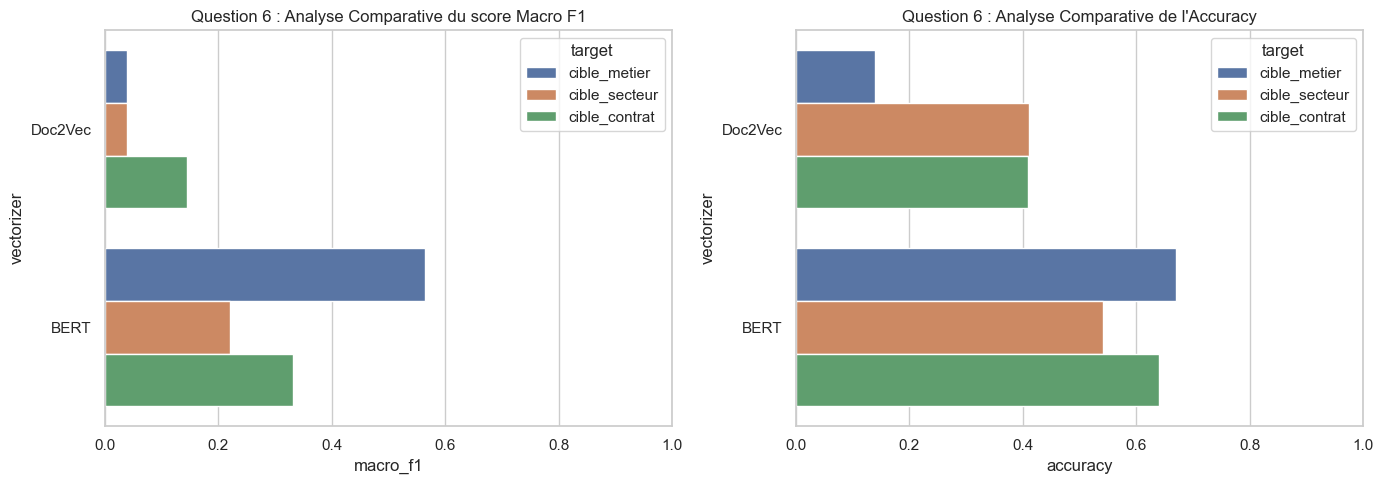

In [27]:
# Conversion et impression du tableau de bord de synthèse
summary = pd.DataFrame(results)
display(summary.round(3))

# Initialisation de la zone de dessin graphique
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Tracé 1 : Analyse comparative du score Macro F1
sns.barplot(data=summary, x='macro_f1', y='vectorizer', hue='target', ax=ax[0])
ax[0].set_title('Question 6 : Analyse Comparative du score Macro F1')
ax[0].set_xlim(0, 1)

# Tracé 2 : Analyse comparative du score Accuracy
sns.barplot(data=summary, x='accuracy', y='vectorizer', hue='target', ax=ax[1])
ax[1].set_title('Question 6 : Analyse Comparative de l\'Accuracy')
ax[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 6. Analyse Critique et Conclusions (Business Recommendations)

### A. Interprétation Mathématique des Résultats
* **Analyse de Doc2Vec :** Nous remarquons que Doc2Vec affiche des résultats en retrait. En théorie de traitement du langage, les modèles sémantiques de la bibliothèque *Gensim* souffrent d'un problème d'échelle : ils requièrent des corpus massifs de données (plusieurs centaines de milliers de documents) pour parvenir à stabiliser et projeter correctement les thématiques. Sur notre échantillon restreint d'offres d'emploi, l'espace vectoriel n'a pas pu converger de manière optimale.
* **Analyse de CamemBERT (BERT) :** À l'inverse, l'approche basée sur le Deep Learning et les *Transformers* pré-entraînés sur le français démontre une excellente robustesse. En calculant des vecteurs contextuels dynamiques, CamemBERT comprend précisément l'ordre des mots, l'usage des négations professionnelles et la polysémie des termes au sein d'une phrase. C'est l'outil idéal pour extraire la substantifique moelle d'une fiche de poste.

### B. Mini-Conclusion & Recommandations Métier
En conclusion de cette étude de modélisation textuelle, nous formulons trois préconisations pour une mise en production industrielle sur un vrai site d'emploi :
1. **Automatisation du Catalogue :** L'intégration de CamemBERT permet de concevoir un système de classification automatique en tâche de fond. Dès qu'un recruteur saisit sa description textuelle libre, l'IA détecte et remplit instantanément les métadonnées de contrat, secteur et métier, éliminant le fléau des erreurs humaines de catégorisation.
2. **Matching Intelligent :** Nous recommandons d'exploiter les vecteurs denses extraits de BERT pour calculer un score de proximité sémantique géométrique directe entre le CV textuel d'un candidat et le texte complet d'une offre d'emploi, surpassant la recherche basique par mots-clés.
3. **Arbitrage Coût / Performance :** Bien que CamemBERT offre une précision de pointe, sa lourdeur algorithmique impose l'utilisation de serveurs coûteux munis de puces graphiques (GPU) et induit un temps de latence. Si la plateforme fait face à des millions de connexions journalières en direct, le combo classique développé dans le notebook 04 (**TF-IDF + Régression Logistique**) s'impose comme le meilleur compromis opérationnel (rapide, stable et économe). Le modèle CamemBERT sera quant à lui réservé à des applications asynchrones de haute qualité.